## 1数据读取

In [1]:
import pandas as pd
import numpy as np
import warnings
import pickle
warnings.filterwarnings("ignore")

In [3]:
close_df=pd.read_parquet('/Users/huangjuyuan/Desktop/因子挖掘:评价/data/limit_ratio_df.pq')

close_df

,000001,000002,000003,000004,000005,000006,000007,000008,000009,000010,...,001393,001365,001237,603435,688635,301669,688797,001399,001248,301583
2013-01-14,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,0.1,0.2
2013-01-15,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,0.1,0.2
2013-01-16,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,0.1,0.2
2013-01-17,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,0.1,0.2
2013-01-18,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,0.1,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-06,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,NaN,0.2
2026-07-07,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,NaN,0.2
2026-07-08,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,NaN,0.2
2026-07-09,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.2,0.2,0.2,0.1,0.1,0.2


## 2设计因子

#### 我们要查看动量因子，即设计10日，20日，60日的动量因子
#### 因子均使用向量计算，这样速度最快

In [3]:
dongliang_10=close_df/close_df.shift(10)
dongliang_20=close_df/close_df.shift(20)
dongliang_60=close_df/close_df.shift(60)

## 3因子评价。即因子ic，ir取得
### 以及因子表现画图

In [4]:
## t日收盘后得到因子，t+1日开盘调仓，持有至t+2日开盘
f1=open_df.shift(-2) / open_df.shift(-1) - 1

In [5]:
f1=open_df.shift(-2) / open_df.shift(-1) - 1
from scipy.stats import spearmanr
def calc_ic(fin_ana_df, factor_name='score',label_name='1D'):
    # 日度横截面 Spearman IC
    df = fin_ana_df.dropna(subset=[factor_name, label_name]).copy()
    return df.groupby('day').apply(
        lambda x: spearmanr(x[factor_name], x[label_name])[0]
    )
def get_ic_info(df, factor_name,label_name):
    ic_series = calc_ic(df, factor_name,label_name)
    ic_mean = ic_series.mean()
    ic_std  = ic_series.std(ddof=1)
    ir = ic_mean / ic_std if ic_std not in (0, np.nan) else np.nan
    return ic_mean, ic_std, np.abs(ir)

def get_melt_df(now_pivot):
    now_pivot.index.name='0'    
    res_df=now_pivot.reset_index().melt(id_vars=now_pivot.index.name)
    res_df.columns=['day','code','values']
    return(res_df)  

In [6]:
f1=get_melt_df(f1)
dongliang_10=get_melt_df(dongliang_10).dropna()
dongliang_20=get_melt_df(dongliang_20).dropna()
dongliang_60=get_melt_df(dongliang_60).dropna()

In [7]:
f1.columns=['day', 'code', 'f1']
dongliang_10.columns=['day', 'code', 'score']
dongliang_10=dongliang_10.merge(f1,on=['day', 'code'],how='left')
ic_mean, ic_std, ir=get_ic_info(dongliang_10, 'score','f1')

In [8]:
ic_mean, ic_std, ir

(-0.037345987853266746, 0.16047997667030747, 0.23271431506991627)

#### 分10组来看结果

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def assign_quantile(df, factor_name='score', n_quantiles=10):
    """
    每日横截面按因子值分成 n 等份（十分位）
    """
    df = df.copy()
    # 使用 rank 分桶，更稳健
    df['group'] = df.groupby('day')[factor_name].rank(pct=True).apply(
        lambda x: min(int(x * n_quantiles), n_quantiles - 1)
    )
    return df

def calc_group_returns(df, group_col='group', ret_col='f1'):
    """
    计算每组每日平均收益（等权）
    """
    group_ret = df.groupby(['day', group_col])[ret_col].mean().reset_index()
    pivot = group_ret.pivot(index='day', columns=group_col, values=ret_col)
    # 按 group 列名排序，G1为因子值最小
    pivot.columns = [f'G{int(c)+1}' for c in pivot.columns]
    pivot['Long-Short'] = pivot['G10'] - pivot['G1']
    return pivot

def plot_group_cumulative(group_return_pivot, title='因子分组累积收益 (十分位)'):
    """
    绘制各组累积收益曲线
    """
    cum_ret = (1 + group_return_pivot).cumprod() - 1
    
    plt.figure(figsize=(14, 7))
    
    # 绘制所有组（排除 Long-Short）
    cols = [c for c in cum_ret.columns if c != 'Long-Short']
    # 颜色映射：从浅到深
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(cols)))[::-1]
    for i, c in enumerate(cols):
        plt.plot(cum_ret.index, cum_ret[c], label=c, color=colors[i], linewidth=1.5, alpha=0.8)
    
    # 突出多空组合
    plt.plot(cum_ret.index, cum_ret['Long-Short'], 
             label='Long-Short (G10-G1)', color='black', linewidth=2.5)
    
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('累积收益', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return cum_ret


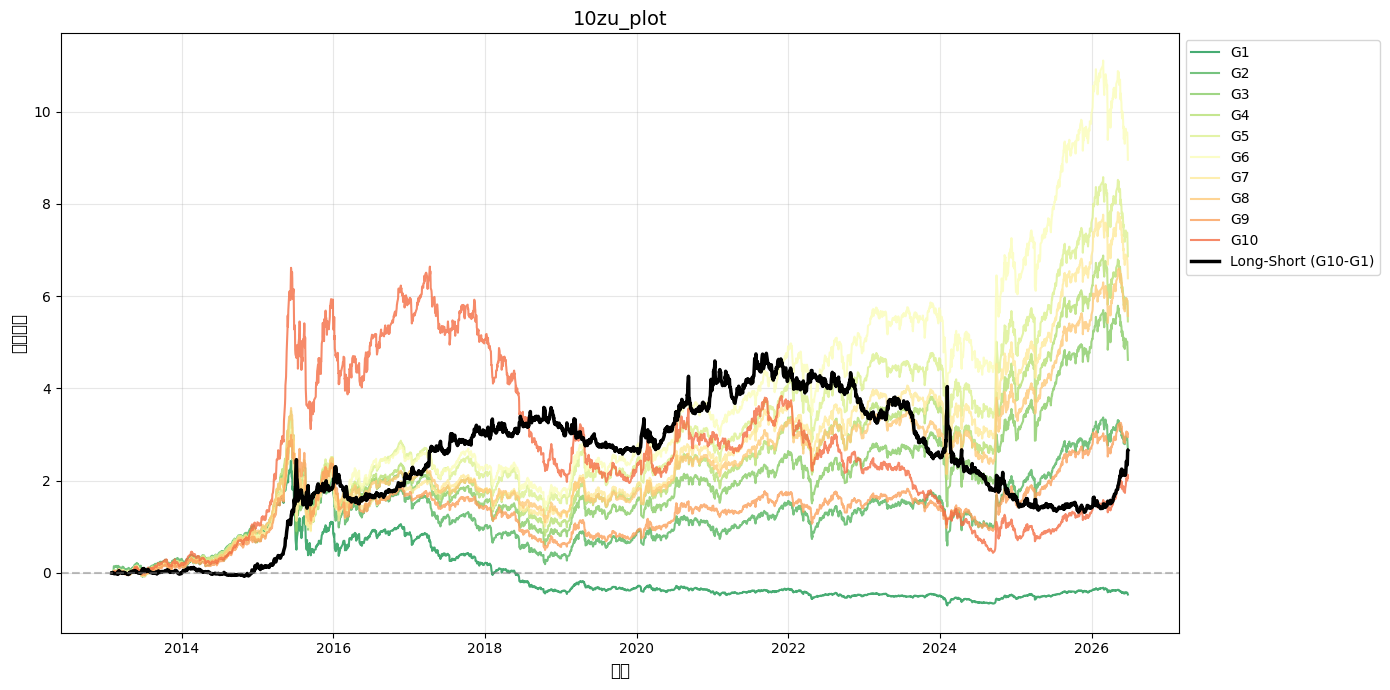

In [10]:

# 1. 分组
df_grouped = assign_quantile(dongliang_10, factor_name='score', n_quantiles=10)

# 2. 计算每组平均收益
group_ret_pivot = calc_group_returns(df_grouped, group_col='group', ret_col='f1')

# 3. 画图
cum_ret = plot_group_cumulative(group_ret_pivot, title='10zu_plot')

## 4 复杂因子构造与评价-课后题

In [ ]:
##评价如下2个因子，并解释因子有效原因
'ts_mean(np.abs((h-l)/(h+l+1e-6)), 20) / (ts_std(amt,20) + 1e-6)'
'ts_std(pct(c),20) / (ts_std(amt,20) + 1e-6)'

#### 其中数据+算子如下

In [12]:
close_df=pd.read_parquet('close_df.pq')
open_df=pd.read_parquet('open_df.pq')
high_df=pd.read_parquet('high_df.pq')
low_df=pd.read_parquet('low_df.pq')
amt_df=pd.read_parquet('amount_df.pq')

hangye_hangqing_df=[close_df,open_df,high_df,low_df,amt_df]

c, o, h, l, amt = hangye_hangqing_df

In [13]:
##使用算子
def roll(x, w): 
    """滚动窗口，axis=0表示按时间滚动"""
    return x.rolling(window=w, min_periods=max(1, w//2), axis=0)

def ts_mean(x, w): 
    return roll(x, w).mean()

def ts_std(x, w): 
    return roll(x, w).std(ddof=0)

### 下午场ai挖因子指南

In [19]:
factor_test1 = eval('ts_mean(np.abs((h-l)/(h+l+1e-6)), 20) / (ts_std(amt,20) + 1e-6)')
factor_test1=get_melt_df(factor_test1).dropna()
f1.columns=['day', 'code', 'f1']
factor_test1.columns=['day', 'code', 'score']
factor_test1=factor_test1.merge(f1,on=['day', 'code'],how='left')
ic_mean, ic_std, ir=get_ic_info(factor_test1, 'score','f1')
ic_mean, ic_std, ir

(0.045423802030017085, 0.1358637426395983, 0.33433351052687726)

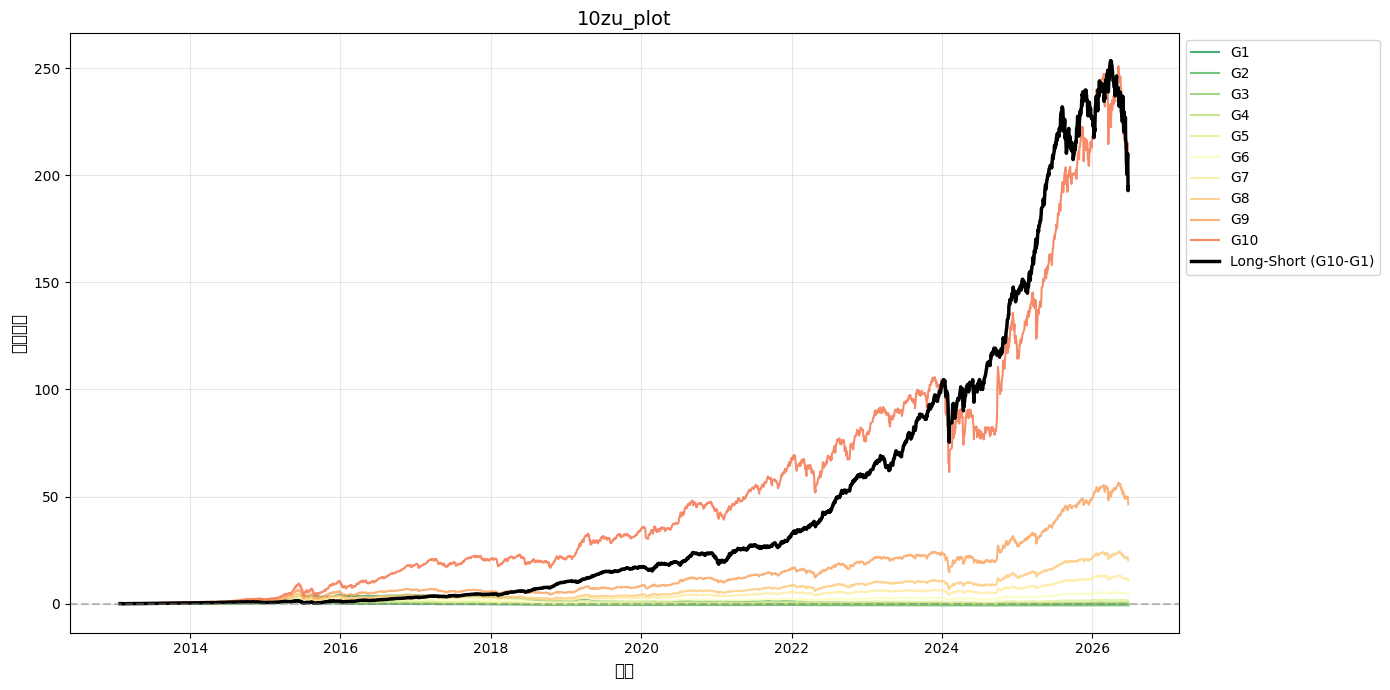

In [20]:

# 1. 分组
df_grouped = assign_quantile(factor_test1, factor_name='score', n_quantiles=10)

# 2. 计算每组平均收益
group_ret_pivot = calc_group_returns(df_grouped, group_col='group', ret_col='f1')

# 3. 画图
cum_ret = plot_group_cumulative(group_ret_pivot, title='10zu_plot')